# Liquidity & Execution Realism — 2025 WNBA Half-Kelly

Generates the liquidity figures and tables used in the paper. Reuses the trading setup from `trading_results2`/`return_investigation` (same model, same best half-Kelly config) and writes outputs to `organized/outputs/`.

**Outputs produced:**
- `liq_equity_ideal_vs_constrained.png` — Headline equity impact
- `liq_fill_rate_vs_wager_size.png` — Fill rate vs required wager size
- `liq_capacity_by_starting_bankroll.png` — Strategy capacity
- `liq_execution_summary_table.csv` — Main execution summary
- `liq_fillability_diagnostics_grid.png` — Appendix diagnostics
- `liq_fillability_counts_table.csv` — Appendix fillability counts
- `liq_execution_method_comparison.png` — Ideal vs sweep vs limit
- `liq_execution_method_table.csv` — Execution-method numbers

In [2]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import math
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import log_loss
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

%matplotlib inline
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 13, 'figure.dpi': 120})

PROJECT_ROOT = Path('../..').resolve()
GOLD_DIR     = PROJECT_ROOT / 'data' / 'gold'
KALSHI_DIR   = PROJECT_ROOT / 'data' / 'kalshi'
OUT_DIR      = PROJECT_ROOT / 'data' / 'trading_results'
OUTPUTS_DIR  = PROJECT_ROOT / 'outputs'
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name):
    path = OUTPUTS_DIR / f'{name}.png'
    fig.savefig(path, dpi=200, bbox_inches='tight')
    print(f'  saved: {path.relative_to(PROJECT_ROOT)}')

def save_table(df, name):
    path = OUTPUTS_DIR / f'{name}.csv'
    df.to_csv(path, index=False)
    print(f'  saved: {path.relative_to(PROJECT_ROOT)}')

# ── Final locked hyperparameters (identical to trading_results2) ──
XGB_PARAMS = dict(
    objective='binary:logistic', eval_metric='logloss',
    max_depth=6, min_child_weight=3, subsample=0.8,
    colsample_bytree=0.6, reg_lambda=1.0, reg_alpha=0.0,
    gamma=0.1, learning_rate=0.02, seed=42, nthread=-1,
)
N_PLAYERS  = 7
MAX_ROUNDS = 3000
EARLY_STOP = 150
CLIP_EPS   = 1e-7
LABEL_COL  = 'home_win'
BANKROLL_INIT = 100.0
BANKROLL_REAL = 5000.0

PLAYER_FEATS = ['m_ewma_pre','q_pre','days_since_first_report_pre','days_since_last_dnp_pre',
                'consec_dnps_pre','played_last_game_pre','minutes_last_game_pre',
                'days_since_last_played_pre','injury_present_flag_pre']
FORM_FEATS   = ['net_rtg_ewma_pre','efg_ewma_pre','tov_pct_ewma_pre','orb_pct_ewma_pre','ftr_ewma_pre']
STYLE_FEATS  = ['off_3pa_rate_pre','def_3pa_allowed_pre','off_2pa_rate_pre','def_2pa_allowed_pre',
                'off_tov_pct_pre','def_forced_tov_pre']
SCHED_FEATS  = ['days_rest_pre','is_b2b_pre','games_last_4_days_pre','games_last_7_days_pre',
                'travel_miles_pre','timezone_shift_hours_pre']

def build_feature_cols(n):
    cols = [f'{s}_p{k}_{f}' for s in ('home','away') for k in range(1, n+1) for f in PLAYER_FEATS]
    for f in FORM_FEATS + STYLE_FEATS + SCHED_FEATS:
        cols += [f'home_{f}', f'away_{f}']
    return cols

FEAT_COLS = build_feature_cols(N_PLAYERS)

def clip(p): return np.clip(p, CLIP_EPS, 1 - CLIP_EPS)

def load_year(year):
    df = pd.read_csv(GOLD_DIR / f'game_xgboost_input_{year}_REGPST.csv')
    cold = (df['home_p1_m_ewma_pre'] == 0) | (df['away_p1_m_ewma_pre'] == 0)
    return df[~cold].reset_index(drop=True)

def make_dm(df, use_bm=True):
    avail = [c for c in FEAT_COLS if c in df.columns]
    y = df[LABEL_COL].values.astype(float) if LABEL_COL in df.columns else None
    dm = xgb.DMatrix(df[avail].values.astype(float), label=y,
                     feature_names=avail, missing=np.nan)
    if use_bm and 'base_margin' in df.columns:
        dm.set_base_margin(df['base_margin'].values.astype(float))
    return dm

def kalshi_taker_fee(n_contracts, price):
    raw = 0.07 * n_contracts * price * (1 - price)
    return math.ceil(raw * 100) / 100

print(f'Outputs directory: {OUTPUTS_DIR}')

Outputs directory: C:\Users\arius\Desktop\kalshi_wnba_bot\organized\outputs


In [3]:
# --- Train final model (identical to trading_results2 / return_investigation) ---
all_data = {yr: load_year(yr) for yr in range(2015, 2026)}
test_2025 = all_data[2025]
es_tr     = pd.concat([all_data[yr] for yr in range(2015, 2024)], ignore_index=True)
val_df    = all_data[2024]
full_tr   = pd.concat([all_data[yr] for yr in range(2015, 2025)], ignore_index=True)

m_es = xgb.train(
    XGB_PARAMS, make_dm(es_tr), MAX_ROUNDS,
    evals=[(make_dm(val_df), 'val')],
    early_stopping_rounds=EARLY_STOP, verbose_eval=False,
)
best_round = m_es.best_iteration + 1
m_final = xgb.train(XGB_PARAMS, make_dm(full_tr), best_round, verbose_eval=False)

p_full_model = clip(m_final.predict(make_dm(test_2025)))
p_elo = clip(test_2025['p_elo'].values.astype(float))

signals = test_2025[['game_id','game_ts','game_date','home_team_id','away_team_id', LABEL_COL]].copy()
signals['p_full_model'] = p_full_model
signals['p_elo']        = p_elo
signals['game_ts']      = pd.to_datetime(signals['game_ts'], utc=True)
signals['game_date']    = pd.to_datetime(signals['game_date'])

y25 = test_2025[LABEL_COL].values.astype(float)
print(f'2025 holdout: {len(signals)} games  |  full-model log-loss: {log_loss(y25, p_full_model):.4f}')

2025 holdout: 310 games  |  full-model log-loss: 0.6121


In [4]:
# --- Load Kalshi market data & build candle index (identical to trading_results2) ---
k_matched = pd.read_csv(KALSHI_DIR / 'wnba_2025_game_markets_matched.csv')
k_markets = pd.read_csv(KALSHI_DIR / 'kalshi_markets.csv',
                         usecols=['market_ticker', 'event_ticker', 'yes_sub_title', 'result'])
k_settle = pd.read_csv(KALSHI_DIR / 'kalshi_settlements.csv',
                        usecols=['market_ticker', 'result', 'settlement_value_dollars'])

game_market_k = (
    k_matched[['event_ticker', 'game_id', 'team_a', 'team_a_id', 'team_b', 'team_b_id']]
    .merge(k_markets, on='event_ticker', how='inner')
)
game_market_k = game_market_k.merge(
    signals[['game_id', 'home_team_id', 'away_team_id', 'game_ts',
             'p_full_model', 'p_elo', LABEL_COL]],
    on='game_id', how='inner',
)
game_market_k['ticker_team_id'] = np.where(
    game_market_k['yes_sub_title'] == game_market_k['team_a'],
    game_market_k['team_a_id'], game_market_k['team_b_id'],
)
game_market_k['is_home_ticker'] = game_market_k['ticker_team_id'] == game_market_k['home_team_id']
home_tickers_k = game_market_k[game_market_k['is_home_ticker']].drop_duplicates('game_id').copy()
home_tickers_k = home_tickers_k.merge(
    k_settle[['market_ticker', 'result']].rename(columns={'result': 'settle_result'}),
    on='market_ticker', how='left',
)

candles = pd.read_csv(KALSHI_DIR / 'kalshi_candles_1m.csv',
                       usecols=['market_ticker', 'end_period_ts', 'yes_bid_close', 'yes_ask_close'])
candles['ts'] = pd.to_datetime(candles['end_period_ts'], utc=True)
candles = candles[candles['market_ticker'].isin(set(home_tickers_k['market_ticker']))].copy()
candles = candles.sort_values(['market_ticker', 'ts']).reset_index(drop=True)

k_matched_ts = pd.read_csv(KALSHI_DIR / 'wnba_2025_game_markets_matched.csv',
                            usecols=['event_ticker', 'open_time'])
k_matched_ts['open_time'] = pd.to_datetime(k_matched_ts['open_time'], utc=True)
open_times = k_matched_ts.set_index('event_ticker')['open_time'].to_dict()
home_tickers_k['open_time'] = home_tickers_k['event_ticker'].map(open_times)

ticker_info = home_tickers_k.set_index('market_ticker')[
    ['game_id', 'game_ts', 'open_time', 'p_full_model', 'p_elo', LABEL_COL]
].to_dict('index')

for ticker, info in ticker_info.items():
    lifespan = info['game_ts'] - info['open_time']
    info['entry_start_half'] = info['open_time'] + lifespan * 0.50
    info['entry_start_twothirds'] = info['open_time'] + lifespan * (2/3)
    info['lifespan_h'] = lifespan.total_seconds() / 3600

pretip = {}
for ticker, info in ticker_info.items():
    sub = candles[(candles['market_ticker'] == ticker) &
                  (candles['ts'] >= info['entry_start_half']) &
                  (candles['ts'] <= info['game_ts'])].copy()
    if not sub.empty:
        pretip[ticker] = sub[['ts', 'yes_bid_close', 'yes_ask_close']].reset_index(drop=True)

game_ts_map = signals.set_index('game_id')['game_ts'].to_dict()
game_dt_map = signals.set_index('game_id')['game_date'].to_dict()

print(f'Matched games: {len(ticker_info)}  |  with pre-tipoff candles: {len(pretip)}')

Matched games: 296  |  with pre-tipoff candles: 296


In [5]:
# --- Trading engines (collected from trading_results2 / return_investigation) ---

def collect_entries(model_col, edge_min, norm_edge_min, entry_window):
    """Scan every 15 min; enter at first qualifying snapshot."""
    key = 'entry_start_half' if entry_window == 'half_life' else 'entry_start_twothirds'
    entries = []
    for ticker, info in ticker_info.items():
        if ticker not in pretip:
            continue
        p, hw = info[model_col], info[LABEL_COL]
        eligible = pretip[ticker][pretip[ticker]['ts'] >= info[key]]
        for _, row in eligible.iterrows():
            if row['ts'].minute % 15 != 0:
                continue
            yb, ya = row['yes_bid_close'], row['yes_ask_close']
            if not (0 < yb < 1 and 0 < ya < 1):
                continue
            q_yes, q_no = ya, 1 - yb
            edge_yes, edge_no = p - q_yes, (1 - p) - q_no
            if edge_yes >= edge_no:
                side, entry_px, edge, p_side = 'YES', q_yes, edge_yes, p
            else:
                side, entry_px, edge, p_side = 'NO', q_no, edge_no, 1 - p
            if edge < edge_min:
                continue
            norm_edge = edge / entry_px if entry_px > 0 else 0
            if norm_edge_min > 0 and norm_edge < norm_edge_min:
                continue
            entries.append({'game_id': info['game_id'], 'game_ts': info['game_ts'],
                            'side': side, 'entry_px': entry_px, 'entry_ts': row['ts'],
                            'edge': edge, 'norm_edge': norm_edge,
                            'p_side': p_side, 'p_model': p, 'home_win': hw})
            break
    return entries


def equity_by_payout(tdf, bankroll_init, ts_col='game_ts'):
    """Sort trades by settlement (payout) time and recompute the bankroll
    trajectory as `bankroll_init + cumsum(pnl)`. Engines compound in
    entry-timestamp order which on multi-game days produces visual loop-backs;
    this gives a strictly time-monotonic display curve. Per-trade pnl is
    unchanged."""
    out = tdf.sort_values(ts_col).reset_index(drop=True).copy()
    out['display_bankroll'] = bankroll_init + out['pnl'].cumsum()
    return out


def run_kelly_ideal(entries, fraction, bankroll_init):
    """Kelly with infinite-liquidity assumption (ideal)."""
    ents = sorted(entries, key=lambda x: x['entry_ts'])
    bankroll = bankroll_init
    out = []
    for e in ents:
        kf = max((e['p_side'] - e['entry_px']) / (1 - e['entry_px']), 0)
        wager = kf * fraction * bankroll
        if wager < 0.01:
            continue
        n = wager / e['entry_px']
        fee = kalshi_taker_fee(n, e['entry_px'])
        pay = 1.0 if (e['side']=='YES' and e['home_win']==1) or (e['side']=='NO' and e['home_win']==0) else 0.0
        pnl = n * pay - wager - fee
        bankroll += pnl
        out.append({**e, 'kelly_f': kf, 'wager_ideal': wager, 'wager': wager,
                    'n_ideal': n, 'n_contracts': n, 'fill_pct': 1.0,
                    'entry_px_actual': e['entry_px'],
                    'fee': fee, 'pnl': pnl, 'won': int(pnl > 0), 'bankroll': bankroll})
    return out


def run_kelly_sweep(entries, fraction, bankroll_init, trade_data):
    """Sweep: take any historical trade at-or-below entry price, VWAP fill."""
    ents = sorted(entries, key=lambda x: x['entry_ts'])
    bankroll = bankroll_init
    out = []
    for e in ents:
        kf = max((e['p_side'] - e['entry_px']) / (1 - e['entry_px']), 0)
        wager_ideal = kf * fraction * bankroll
        if wager_ideal < 0.01:
            continue
        n_ideal = wager_ideal / e['entry_px']
        gtr = trade_data[trade_data['game_id'] == e['game_id']].copy()
        if gtr.empty:
            continue
        gtr['our_price'] = gtr['yes_price'] if e['side']=='YES' else gtr['no_price']
        qual = gtr[gtr['our_price'] <= e['entry_px']].sort_values('our_price')
        if qual.empty:
            continue
        filled, cost = 0.0, 0.0
        for _, t in qual.iterrows():
            can_take = min(t['count'], n_ideal - filled)
            filled += can_take
            cost += can_take * t['our_price']
            if filled >= n_ideal:
                break
        if filled == 0:
            continue
        vwap = cost / filled
        n_actual = filled
        wager_actual = cost
        fee = kalshi_taker_fee(n_actual, vwap)
        pay = 1.0 if (e['side']=='YES' and e['home_win']==1) or (e['side']=='NO' and e['home_win']==0) else 0.0
        pnl = n_actual * pay - wager_actual - fee
        bankroll += pnl
        out.append({**e, 'kelly_f': kf,
                    'wager_ideal': wager_ideal, 'wager': wager_actual,
                    'n_ideal': n_ideal, 'n_contracts': n_actual,
                    'fill_pct': n_actual / n_ideal if n_ideal > 0 else 0,
                    'entry_px_actual': vwap,
                    'fee': fee, 'pnl': pnl, 'won': int(pnl > 0), 'bankroll': bankroll})
    return out


def run_kelly_limit(entries, fraction, bankroll_init, trade_data):
    """Limit order: only fill against historical volume at exactly our entry price."""
    ents = sorted(entries, key=lambda x: x['entry_ts'])
    bankroll = bankroll_init
    out = []
    for e in ents:
        kf = max((e['p_side'] - e['entry_px']) / (1 - e['entry_px']), 0)
        wager_ideal = kf * fraction * bankroll
        if wager_ideal < 0.01:
            continue
        n_ideal = wager_ideal / e['entry_px']
        gtr = trade_data[trade_data['game_id'] == e['game_id']].copy()
        if gtr.empty:
            continue
        gtr['our_price'] = gtr['yes_price'] if e['side']=='YES' else gtr['no_price']
        at_px = gtr[gtr['our_price'] == e['entry_px']]
        vol_at = at_px['count'].sum()
        if vol_at == 0:
            continue
        n_actual = min(n_ideal, vol_at)
        wager_actual = n_actual * e['entry_px']
        fee = kalshi_taker_fee(n_actual, e['entry_px'])
        pay = 1.0 if (e['side']=='YES' and e['home_win']==1) or (e['side']=='NO' and e['home_win']==0) else 0.0
        pnl = n_actual * pay - wager_actual - fee
        bankroll += pnl
        out.append({**e, 'kelly_f': kf,
                    'wager_ideal': wager_ideal, 'wager': wager_actual,
                    'n_ideal': n_ideal, 'n_contracts': n_actual,
                    'fill_pct': n_actual / n_ideal if n_ideal > 0 else 0,
                    'entry_px_actual': e['entry_px'],
                    'fee': fee, 'pnl': pnl, 'won': int(pnl > 0), 'bankroll': bankroll})
    return out


def fill_diagnostics(trades_df, trade_data):
    """Per-trade fill diagnostics at the wager sizes in trades_df."""
    rows = []
    for _, t in trades_df.iterrows():
        gid = t['game_id']; side = t['side']; entry_px = t['entry_px']
        n_needed = t['n_contracts']
        gtr = trade_data[trade_data['game_id'] == gid].copy()
        if gtr.empty:
            rows.append({'game_id': gid, 'side': side, 'entry_px': entry_px,
                         'wager': t['wager'], 'n_needed': n_needed,
                         'total_volume': 0, 'volume_at_or_below': 0,
                         'vol_at_price': 0, 'vwap': np.nan, 'fill_pct': 0,
                         'limit_fill_pct': 0})
            continue
        gtr['our_price'] = gtr['yes_price'] if side=='YES' else gtr['no_price']
        total_vol = gtr['count'].sum()
        qual = gtr[gtr['our_price'] <= entry_px]
        vol_below = qual['count'].sum()
        at_px = gtr[gtr['our_price'] == entry_px]
        vol_at = at_px['count'].sum()
        qual_sorted = qual.sort_values('our_price')
        filled, cost = 0.0, 0.0
        for _, r in qual_sorted.iterrows():
            take = min(r['count'], n_needed - filled)
            filled += take
            cost += take * r['our_price']
            if filled >= n_needed:
                break
        vwap = cost / filled if filled > 0 else np.nan
        fill_pct = min(filled / n_needed, 1.0) if n_needed > 0 else 0
        limit_fill_pct = min(vol_at / n_needed, 1.0) if n_needed > 0 else 0
        rows.append({'game_id': gid, 'side': side, 'entry_px': entry_px,
                     'wager': t['wager'], 'n_needed': n_needed,
                     'total_volume': total_vol, 'volume_at_or_below': vol_below,
                     'vol_at_price': vol_at, 'vwap': vwap, 'fill_pct': fill_pct,
                     'limit_fill_pct': limit_fill_pct})
    return pd.DataFrame(rows)

print('Trading engines defined.')

Trading engines defined.


In [6]:
# --- Best half-Kelly config + base entries + window trade data ---
grid = pd.read_csv(OUT_DIR / 'grid_search_v2.csv')
hk_fm = grid[(grid['sizing'] == 'half_kelly') &
             (grid['model'] == 'full_model') &
             (grid['entry_window'] == 'half_life') &
             (grid['n_trades'] > 0)]
best = hk_fm.sort_values('total_return', ascending=False).iloc[0]
BEST_EDGE_MIN = best['edge_min']
BEST_NORM_MIN = best['norm_min']
print(f'Best half-Kelly config: edge_min={BEST_EDGE_MIN}, norm_min={BEST_NORM_MIN}')

entries = collect_entries('p_full_model', BEST_EDGE_MIN, BEST_NORM_MIN, 'half_life')
print(f'Qualifying entries: {len(entries)}')

# Historical trades inside entry windows (half-life → tipoff)
trades_raw = pd.read_csv(KALSHI_DIR / 'kalshi_trades.csv',
                         usecols=['market_ticker', 'trade_ts', 'yes_price', 'no_price', 'count', 'taker_side'])
trades_raw['ts'] = pd.to_datetime(trades_raw['trade_ts'], utc=True)
trades_raw = trades_raw[trades_raw['market_ticker'].isin(set(ticker_info.keys()))].copy()

window_trades = []
for ticker, info in ticker_info.items():
    sub = trades_raw[(trades_raw['market_ticker'] == ticker) &
                     (trades_raw['ts'] >= info['entry_start_half']) &
                     (trades_raw['ts'] <= info['game_ts'])].copy()
    if not sub.empty:
        sub['game_id'] = info['game_id']
        window_trades.append(sub)
wt = pd.concat(window_trades, ignore_index=True) if window_trades else pd.DataFrame()
print(f'Trades inside entry window: {len(wt):,} across {wt["game_id"].nunique()} games')

Best half-Kelly config: edge_min=0.05, norm_min=0.25
Qualifying entries: 134
Trades inside entry window: 34,062 across 296 games


---
## 1. Headline equity impact
**Figure:** `liq_equity_ideal_vs_constrained` — Ideal vs liquidity-constrained equity curves (\$5,000 starting bankroll).

  saved: outputs\liq_equity_ideal_vs_constrained.png


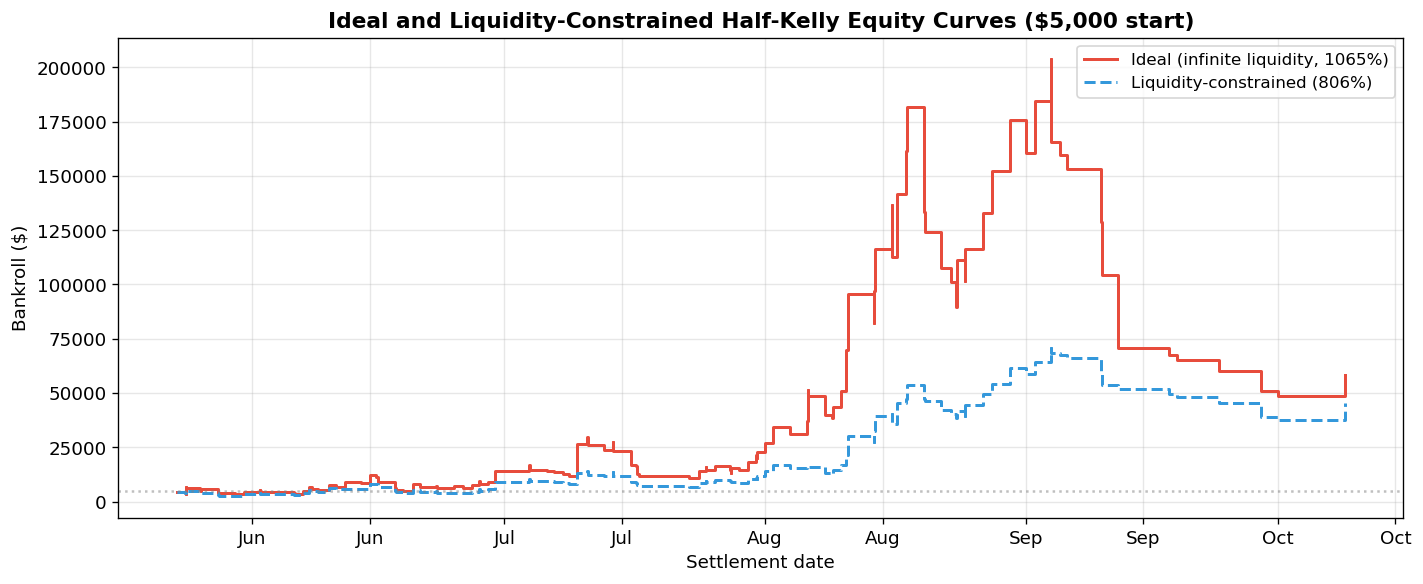

In [7]:
# Ideal and sweep at $5,000 bankroll
tdf_ideal_5k = pd.DataFrame(run_kelly_ideal(entries, 0.5, BANKROLL_REAL))
tdf_sweep_5k = pd.DataFrame(run_kelly_sweep(entries, 0.5, BANKROLL_REAL, wt))
tdf_limit_5k = pd.DataFrame(run_kelly_limit(entries, 0.5, BANKROLL_REAL, wt))

for d in (tdf_ideal_5k, tdf_sweep_5k, tdf_limit_5k):
    if len(d) > 0:
        d['game_date'] = pd.to_datetime(d['game_id'].map(game_dt_map))

# Equity curves are sorted by settlement (payout) time so the date axis is
# monotonic — engines compound in entry-timestamp order, which produces visual
# loop-backs on multi-game days.
eq_ideal_5k = equity_by_payout(tdf_ideal_5k, BANKROLL_REAL, ts_col='game_ts')
eq_sweep_5k = equity_by_payout(tdf_sweep_5k, BANKROLL_REAL, ts_col='game_ts')

ret_ideal_5k = (eq_ideal_5k['display_bankroll'].iloc[-1] - BANKROLL_REAL) / BANKROLL_REAL
ret_sweep_5k = (eq_sweep_5k['display_bankroll'].iloc[-1] - BANKROLL_REAL) / BANKROLL_REAL
if len(tdf_limit_5k) > 0:
    eq_limit_5k = equity_by_payout(tdf_limit_5k, BANKROLL_REAL, ts_col='game_ts')
    ret_limit_5k = (eq_limit_5k['display_bankroll'].iloc[-1] - BANKROLL_REAL) / BANKROLL_REAL
else:
    eq_limit_5k = tdf_limit_5k
    ret_limit_5k = np.nan

fig, ax = plt.subplots(figsize=(12, 5))
ax.step(eq_ideal_5k['game_ts'], eq_ideal_5k['display_bankroll'], where='post',
        color='#e74c3c', linewidth=1.8,
        label=f'Ideal (infinite liquidity, {ret_ideal_5k:.0%})')
ax.step(eq_sweep_5k['game_ts'], eq_sweep_5k['display_bankroll'], where='post',
        color='#3498db', linewidth=1.8, linestyle='--',
        label=f'Liquidity-constrained ({ret_sweep_5k:.0%})')
ax.axhline(BANKROLL_REAL, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Settlement date'); ax.set_ylabel('Bankroll ($)')
ax.set_title('Ideal and Liquidity-Constrained Half-Kelly Equity Curves ($5,000 start)', fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b'))
plt.tight_layout()
save_fig(fig, 'liq_equity_ideal_vs_constrained')
plt.show()

---
## 2. Liquidity mechanism
**Figure:** `liq_fill_rate_vs_wager_size` — fill rate as a function of intended wager size.

  saved: outputs\liq_fill_rate_vs_wager_size.png


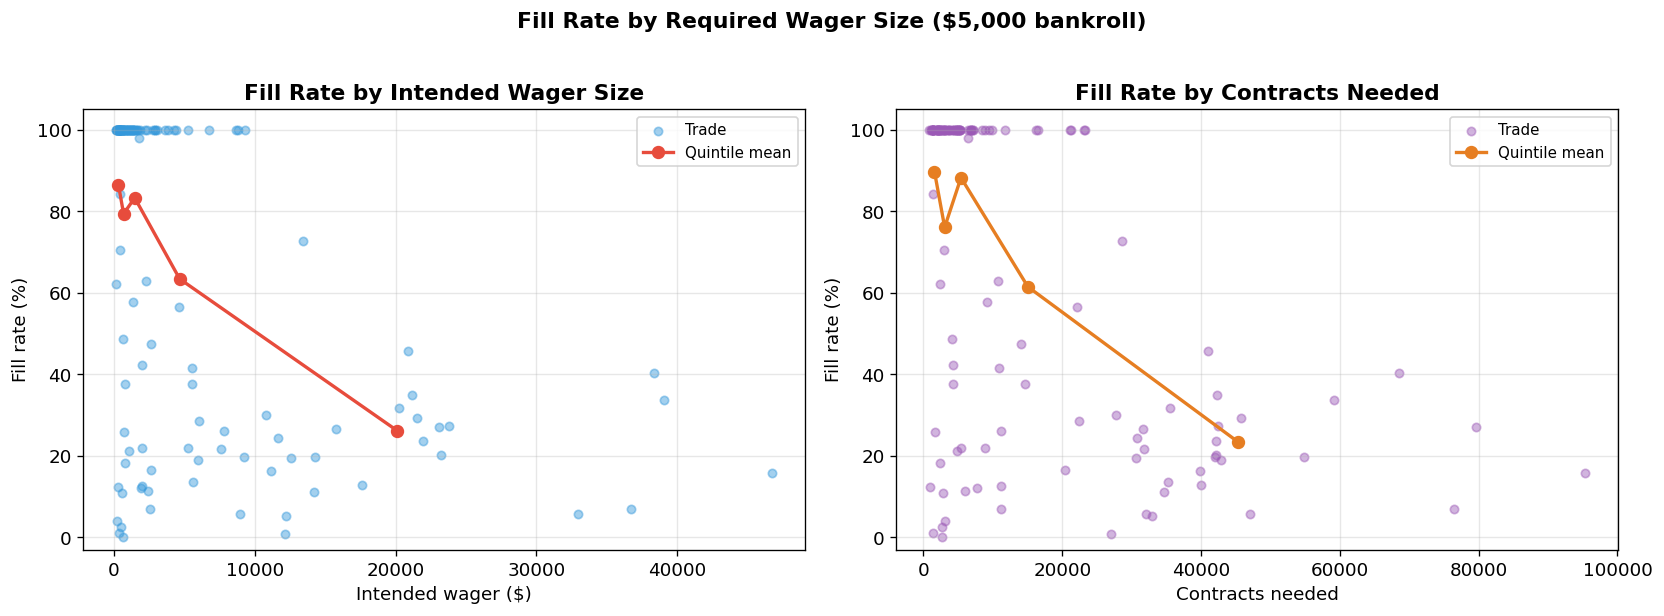

In [8]:
# Diagnostics at $5k scale (uses ideal contract sizes from tdf_ideal_5k)
fdf_5k = fill_diagnostics(tdf_ideal_5k, wt)
fdf_5k['game_date'] = pd.to_datetime(fdf_5k['game_id'].map(game_dt_map))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) scatter + binned-mean fill rate vs intended wager
ax = axes[0]
ax.scatter(fdf_5k['wager'], fdf_5k['fill_pct'] * 100, alpha=0.45, s=25, color='#3498db', label='Trade')
if len(fdf_5k) >= 5:
    bins = pd.qcut(fdf_5k['wager'], q=5, duplicates='drop')
    grp = fdf_5k.groupby(bins, observed=True).agg(mean_wager=('wager','mean'), mean_fill=('fill_pct','mean'))
    ax.plot(grp['mean_wager'], grp['mean_fill'] * 100, 'o-', color='#e74c3c',
            linewidth=2, markersize=7, label='Quintile mean')
ax.set_xlabel('Intended wager ($)'); ax.set_ylabel('Fill rate (%)')
ax.set_title('Fill Rate by Intended Wager Size', fontweight='bold')
ax.set_ylim(-3, 105)
ax.grid(True, alpha=0.3); ax.legend(fontsize=9)

# (b) same but x = contracts needed (Kelly-scaled position size)
ax = axes[1]
ax.scatter(fdf_5k['n_needed'], fdf_5k['fill_pct'] * 100, alpha=0.45, s=25, color='#9b59b6', label='Trade')
if len(fdf_5k) >= 5:
    bins2 = pd.qcut(fdf_5k['n_needed'], q=5, duplicates='drop')
    grp2 = fdf_5k.groupby(bins2, observed=True).agg(mean_n=('n_needed','mean'), mean_fill=('fill_pct','mean'))
    ax.plot(grp2['mean_n'], grp2['mean_fill'] * 100, 'o-', color='#e67e22',
            linewidth=2, markersize=7, label='Quintile mean')
ax.set_xlabel('Contracts needed'); ax.set_ylabel('Fill rate (%)')
ax.set_title('Fill Rate by Contracts Needed', fontweight='bold')
ax.set_ylim(-3, 105)
ax.grid(True, alpha=0.3); ax.legend(fontsize=9)

fig.suptitle('Fill Rate by Required Wager Size ($5,000 bankroll)', fontweight='bold', y=1.02)
plt.tight_layout()
save_fig(fig, 'liq_fill_rate_vs_wager_size')
plt.show()

---
## 3. Capacity / scalability
**Figure:** `liq_capacity_by_starting_bankroll` — how returns and fill rate evolve as bankroll grows.

In [9]:
BANKROLL_LEVELS = [100, 500, 1000, 2500, 5000, 7500, 10000]

br_results = []
br_trade_frames = {}
for br in BANKROLL_LEVELS:
    t_ideal = run_kelly_ideal(entries, 0.5, br)
    t_sweep = run_kelly_sweep(entries, 0.5, br, wt)
    df_ideal = pd.DataFrame(t_ideal); df_sweep = pd.DataFrame(t_sweep)
    fb_ideal = df_ideal['bankroll'].iloc[-1] if len(df_ideal) else br
    fb_sweep = df_sweep['bankroll'].iloc[-1] if len(df_sweep) else br
    diag = fill_diagnostics(df_ideal, wt) if len(df_ideal) else pd.DataFrame()
    br_trade_frames[br] = {'ideal': df_ideal, 'sweep': df_sweep, 'diag': diag}
    br_results.append({
        'bankroll': br,
        'ideal_final': fb_ideal, 'ideal_return': (fb_ideal - br) / br,
        'sweep_final': fb_sweep, 'sweep_return': (fb_sweep - br) / br,
        'n_trades_ideal': len(df_ideal), 'n_trades_sweep': len(df_sweep),
        'mean_fill_sweep': df_sweep['fill_pct'].mean() if len(df_sweep) else 0,
        'median_fill_sweep': df_sweep['fill_pct'].median() if len(df_sweep) else 0,
    })
rdf = pd.DataFrame(br_results)
print(rdf.to_string(index=False))

 bankroll   ideal_final  ideal_return  sweep_final  sweep_return  n_trades_ideal  n_trades_sweep  mean_fill_sweep  median_fill_sweep
      100   1161.785792     10.617858  2646.649457     25.466495             134             134         0.981039                1.0
      500   5821.901454     10.643803  9940.246835     18.880494             134             134         0.947784                1.0
     1000  11646.604187     10.646604 15391.292500     14.391292             134             134         0.916811                1.0
     2500  29121.331158     10.648532 34024.108583     12.609643             134             134         0.843647                1.0
     5000  58245.690756     10.649138 45276.149126      8.055230             134             134         0.794425                1.0
     7500  87370.338396     10.649378 57114.978022      6.615330             134             134         0.755442                1.0
    10000 116494.446171     10.649445 67734.883149      5.773488     

  saved: outputs\liq_capacity_by_starting_bankroll.png


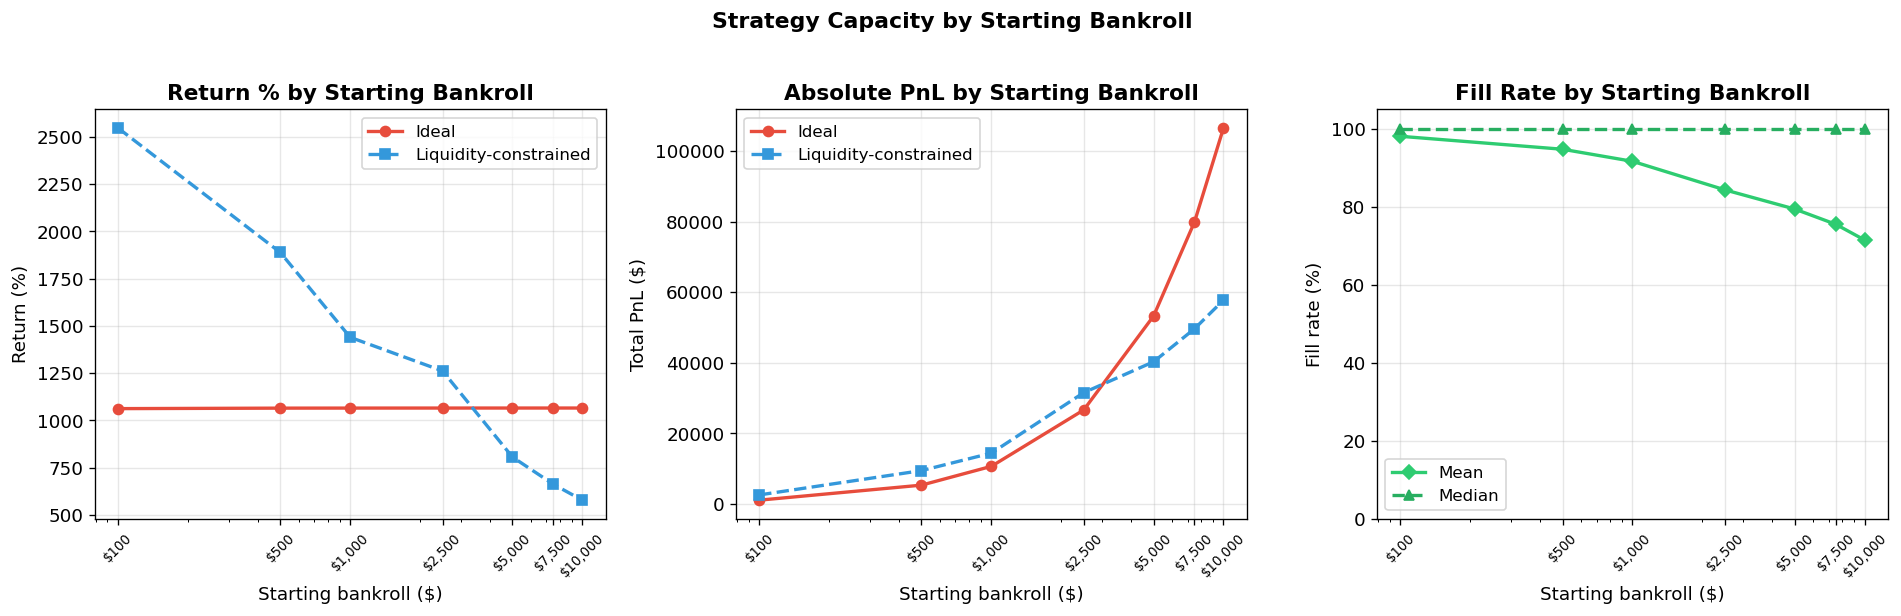

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
bankrolls = rdf['bankroll'].values

ax = axes[0]
ax.plot(bankrolls, rdf['ideal_return'] * 100, 'o-', color='#e74c3c', lw=2, ms=6, label='Ideal')
ax.plot(bankrolls, rdf['sweep_return'] * 100, 's--', color='#3498db', lw=2, ms=6, label='Liquidity-constrained')
ax.set_xlabel('Starting bankroll ($)'); ax.set_ylabel('Return (%)')
ax.set_title('Return % by Starting Bankroll', fontweight='bold')
ax.set_xscale('log'); ax.set_xticks(bankrolls)
ax.set_xticklabels([f'${b:,.0f}' for b in bankrolls], rotation=45, fontsize=8)
ax.grid(True, alpha=0.3); ax.legend(fontsize=10)

ax = axes[1]
ax.plot(bankrolls, rdf['ideal_final'] - rdf['bankroll'], 'o-', color='#e74c3c', lw=2, ms=6, label='Ideal')
ax.plot(bankrolls, rdf['sweep_final'] - rdf['bankroll'], 's--', color='#3498db', lw=2, ms=6, label='Liquidity-constrained')
ax.set_xlabel('Starting bankroll ($)'); ax.set_ylabel('Total PnL ($)')
ax.set_title('Absolute PnL by Starting Bankroll', fontweight='bold')
ax.set_xscale('log'); ax.set_xticks(bankrolls)
ax.set_xticklabels([f'${b:,.0f}' for b in bankrolls], rotation=45, fontsize=8)
ax.grid(True, alpha=0.3); ax.legend(fontsize=10)

ax = axes[2]
ax.plot(bankrolls, rdf['mean_fill_sweep'] * 100, 'D-', color='#2ecc71', lw=2, ms=6, label='Mean')
ax.plot(bankrolls, rdf['median_fill_sweep'] * 100, '^--', color='#27ae60', lw=2, ms=6, label='Median')
ax.set_xlabel('Starting bankroll ($)'); ax.set_ylabel('Fill rate (%)')
ax.set_title('Fill Rate by Starting Bankroll', fontweight='bold')
ax.set_xscale('log'); ax.set_xticks(bankrolls)
ax.set_xticklabels([f'${b:,.0f}' for b in bankrolls], rotation=45, fontsize=8)
ax.set_ylim(0, 105); ax.grid(True, alpha=0.3); ax.legend(fontsize=10)

fig.suptitle('Strategy Capacity by Starting Bankroll', fontweight='bold', y=1.02)
plt.tight_layout()
save_fig(fig, 'liq_capacity_by_starting_bankroll')
plt.show()

---
## 4. Main execution summary
**Table:** `liq_execution_summary_table` — headline numbers behind the liquidity-constrained simulation, by starting bankroll.

In [11]:
summary_rows = []
for br in BANKROLL_LEVELS:
    df_ideal = br_trade_frames[br]['ideal']
    df_sweep = br_trade_frames[br]['sweep']
    diag = br_trade_frames[br]['diag']
    intended = len(df_ideal)
    executed = len(df_sweep)
    full_n = int((df_sweep['fill_pct'] >= 1.0).sum()) if len(df_sweep) else 0
    partial_n = int(((df_sweep['fill_pct'] > 0) & (df_sweep['fill_pct'] < 1)).sum()) if len(df_sweep) else 0
    fb_ideal = df_ideal['bankroll'].iloc[-1] if len(df_ideal) else br
    fb_sweep = df_sweep['bankroll'].iloc[-1] if len(df_sweep) else br
    ret_ideal = (fb_ideal - br) / br
    ret_sweep = (fb_sweep - br) / br
    haircut = (ret_ideal - ret_sweep) / ret_ideal if ret_ideal != 0 else np.nan
    summary_rows.append({
        'starting_bankroll': br,
        'intended_trades': intended,
        'executed_trades': executed,
        'fully_fillable': full_n,
        'partially_fillable': partial_n,
        'mean_fill_rate': df_sweep['fill_pct'].mean() if len(df_sweep) else 0,
        'median_fill_rate': df_sweep['fill_pct'].median() if len(df_sweep) else 0,
        'ideal_terminal_wealth': fb_ideal,
        'liq_constrained_terminal_wealth': fb_sweep,
        'ideal_return': ret_ideal,
        'liq_constrained_return': ret_sweep,
        'return_haircut': haircut,
    })
summary_tbl = pd.DataFrame(summary_rows)
save_table(summary_tbl, 'liq_execution_summary_table')
summary_tbl

  saved: outputs\liq_execution_summary_table.csv


,starting_bankroll,intended_trades,executed_trades,fully_fillable,partially_fillable,mean_fill_rate,median_fill_rate,ideal_terminal_wealth,liq_constrained_terminal_wealth,ideal_return,liq_constrained_return,return_haircut
0,100,134,134,130,4,0.981039,1.0,1161.785792,2646.649457,10.617858,25.466495,-1.398459
1,500,134,134,121,13,0.947784,1.0,5821.901454,9940.246835,10.643803,18.880494,-0.773848
2,1000,134,134,114,20,0.916811,1.0,11646.604187,15391.292500,10.646604,14.391292,-0.351726
3,2500,134,134,91,43,0.843647,1.0,29121.331158,34024.108583,10.648532,12.609643,-0.184167
4,5000,134,134,84,50,0.794425,1.0,58245.690756,45276.149126,10.649138,8.055230,0.243579
5,7500,134,134,79,55,0.755442,1.0,87370.338396,57114.978022,10.649378,6.615330,0.378806
6,10000,134,134,71,63,0.714958,1.0,116494.446171,67734.883149,10.649445,5.773488,0.457860


---
## Appendix — Liquidity and Execution Diagnostics

### A1. Fillability diagnostics
**Figure:** `liq_fillability_diagnostics_grid` — supporting fill-rate, available-volume, and execution-quality plots ($5,000 bankroll).

  saved: outputs\liq_fillability_diagnostics_grid.png


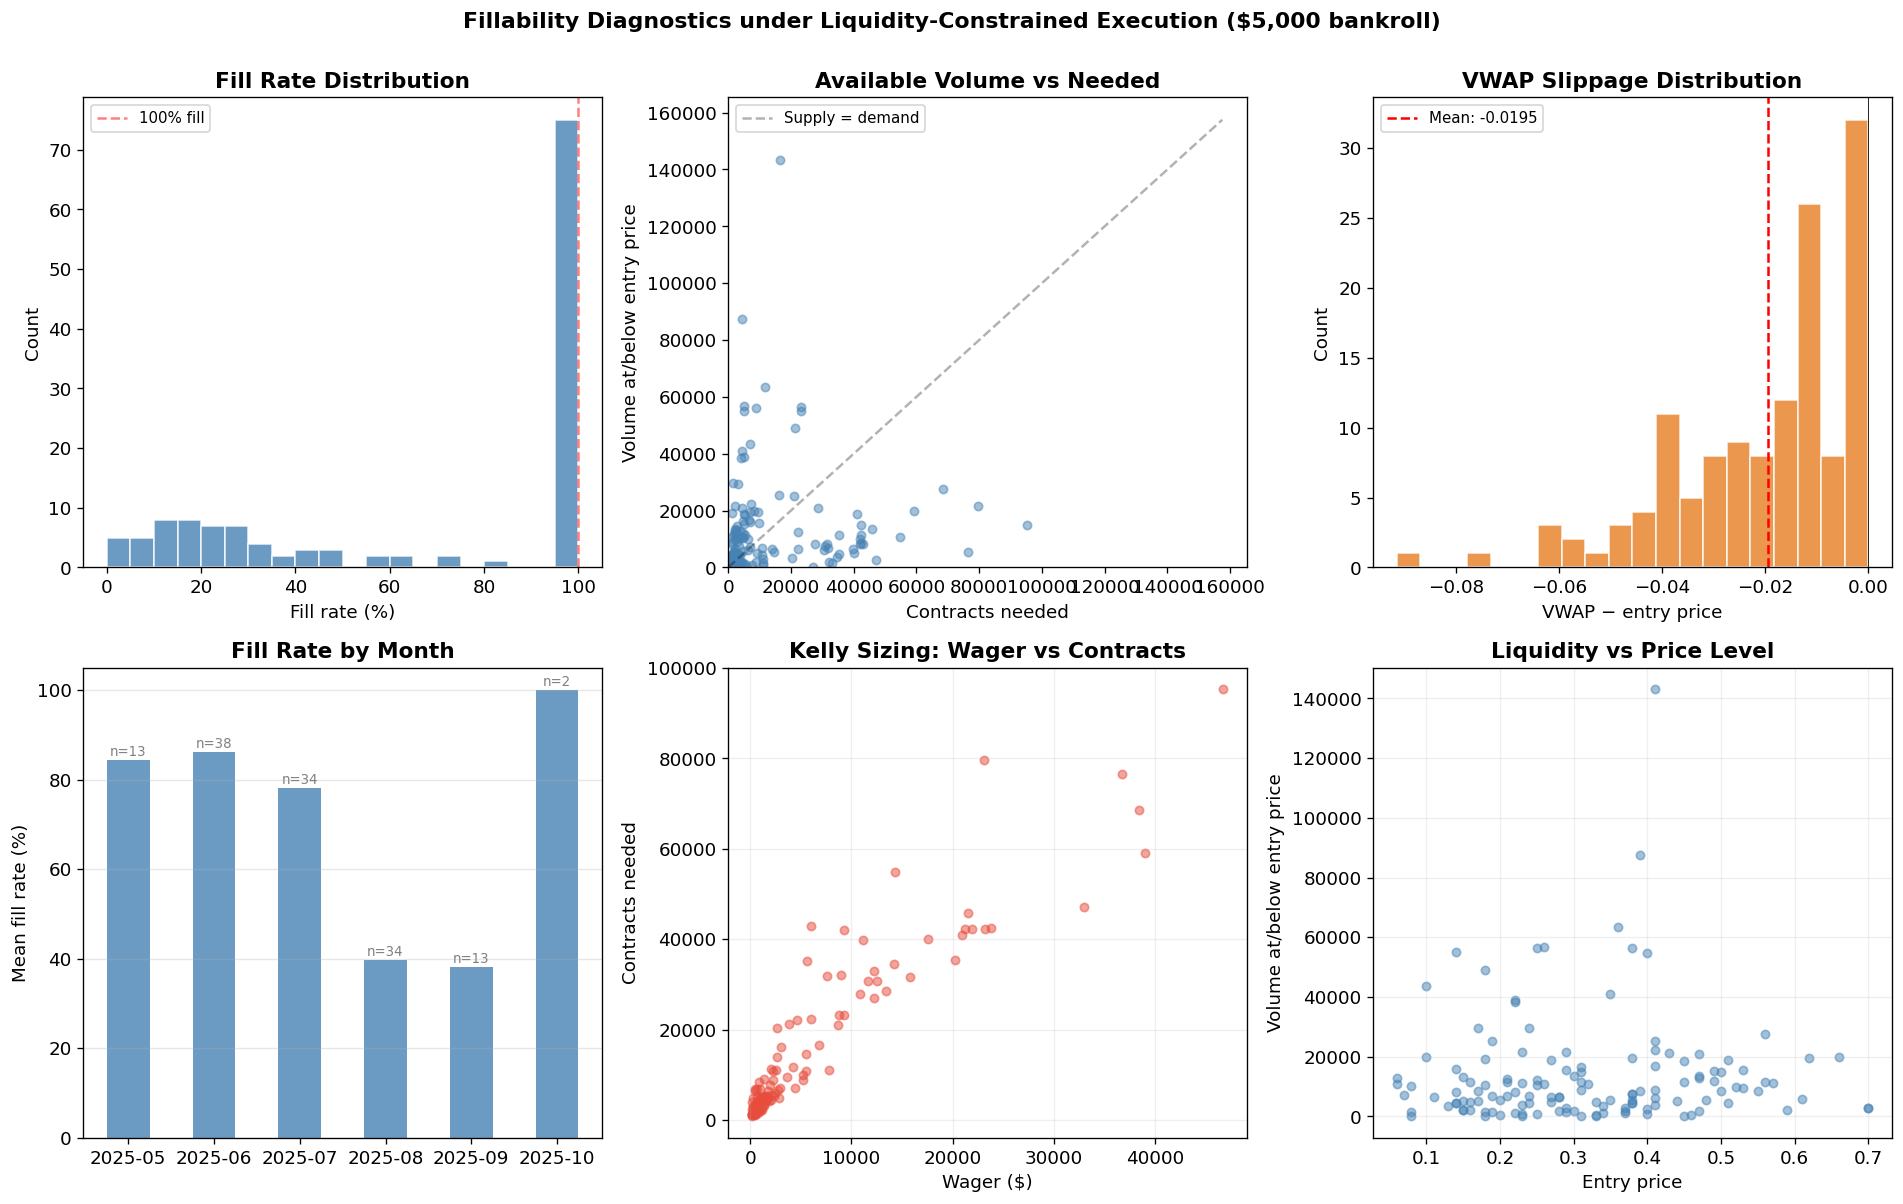

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# (1) fill rate distribution
ax = axes[0, 0]
ax.hist(fdf_5k['fill_pct'] * 100, bins=20, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(100, color='red', linestyle='--', alpha=0.5, label='100% fill')
ax.set_xlabel('Fill rate (%)'); ax.set_ylabel('Count')
ax.set_title('Fill Rate Distribution', fontweight='bold'); ax.legend(fontsize=9)

# (2) available volume vs needed
ax = axes[0, 1]
ax.scatter(fdf_5k['n_needed'], fdf_5k['volume_at_or_below'], alpha=0.5, s=25, color='steelblue')
max_val = max(fdf_5k['n_needed'].max(), fdf_5k['volume_at_or_below'].max()) * 1.1
ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='Supply = demand')
ax.set_xlabel('Contracts needed'); ax.set_ylabel('Volume at/below entry price')
ax.set_title('Available Volume vs Needed', fontweight='bold')
ax.set_xlim(0, None); ax.set_ylim(0, None); ax.legend(fontsize=9)

# (3) VWAP slippage distribution
ax = axes[0, 2]
valid = fdf_5k[fdf_5k['vwap'].notna()].copy()
if len(valid) > 0:
    slip = valid['vwap'] - valid['entry_px']
    ax.hist(slip, bins=20, color='#e67e22', alpha=0.8, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.5)
    ax.axvline(slip.mean(), color='red', linestyle='--', label=f'Mean: {slip.mean():.4f}')
    ax.set_xlabel('VWAP − entry price'); ax.set_ylabel('Count')
    ax.set_title('VWAP Slippage Distribution', fontweight='bold'); ax.legend(fontsize=9)

# (4) fill rate over season
ax = axes[1, 0]
fdf_m = fdf_5k.copy()
fdf_m['month'] = fdf_m['game_date'].dt.to_period('M')
monthly = fdf_m.groupby('month').agg(mean_fill=('fill_pct','mean'), n_trades=('fill_pct','count')).reset_index()
monthly['month_str'] = monthly['month'].astype(str)
bars = ax.bar(monthly['month_str'], monthly['mean_fill'] * 100, color='steelblue', alpha=0.8, width=0.5)
for bar, n in zip(bars, monthly['n_trades']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'n={int(n)}', ha='center', fontsize=8, color='gray')
ax.set_ylabel('Mean fill rate (%)'); ax.set_title('Fill Rate by Month', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# (5) Kelly scaling: wager vs contracts
ax = axes[1, 1]
ax.scatter(fdf_5k['wager'], fdf_5k['n_needed'], alpha=0.5, s=25, color='#e74c3c')
ax.set_xlabel('Wager ($)'); ax.set_ylabel('Contracts needed')
ax.set_title('Kelly Sizing: Wager vs Contracts', fontweight='bold')
ax.grid(True, alpha=0.2)

# (6) liquidity vs price level
ax = axes[1, 2]
ax.scatter(fdf_5k['entry_px'], fdf_5k['volume_at_or_below'], alpha=0.5, s=25, color='steelblue')
ax.set_xlabel('Entry price'); ax.set_ylabel('Volume at/below entry price')
ax.set_title('Liquidity vs Price Level', fontweight='bold')
ax.grid(True, alpha=0.2)

fig.suptitle('Fillability Diagnostics under Liquidity-Constrained Execution ($5,000 bankroll)',
             fontweight='bold', y=1.00)
plt.tight_layout()
save_fig(fig, 'liq_fillability_diagnostics_grid')
plt.show()

### A2. Fillability counts
**Table:** `liq_fillability_counts_table` — exact fully / partially / unfillable counts and percentages by bankroll.

In [13]:
count_rows = []
for br in BANKROLL_LEVELS:
    diag = br_trade_frames[br]['diag']
    if len(diag) == 0:
        continue
    n = len(diag)
    full_n = int((diag['fill_pct'] >= 1.0).sum())
    partial_n = int(((diag['fill_pct'] > 0) & (diag['fill_pct'] < 1)).sum())
    zero_n = int((diag['fill_pct'] == 0).sum())
    count_rows.append({
        'starting_bankroll': br,
        'total_trades': n,
        'fully_fillable': full_n,
        'partially_fillable': partial_n,
        'unfillable': zero_n,
        'pct_fully_fillable': full_n / n,
        'pct_partially_fillable': partial_n / n,
        'pct_unfillable': zero_n / n,
        'mean_fill_rate': diag['fill_pct'].mean(),
        'median_fill_rate': diag['fill_pct'].median(),
    })
counts_tbl = pd.DataFrame(count_rows)
save_table(counts_tbl, 'liq_fillability_counts_table')
counts_tbl

  saved: outputs\liq_fillability_counts_table.csv


,starting_bankroll,total_trades,fully_fillable,partially_fillable,unfillable,pct_fully_fillable,pct_partially_fillable,pct_unfillable,mean_fill_rate,median_fill_rate
0,100,134,131,3,0,0.977612,0.022388,0.0,0.984982,1.000000
1,500,134,124,10,0,0.925373,0.074627,0.0,0.954561,1.000000
2,1000,134,108,26,0,0.805970,0.194030,0.0,0.910671,1.000000
3,2500,134,82,52,0,0.611940,0.388060,0.0,0.775877,1.000000
4,5000,134,74,60,0,0.552239,0.447761,0.0,0.676363,1.000000
5,7500,134,64,70,0,0.477612,0.522388,0.0,0.623114,0.874378
6,10000,134,60,74,0,0.447761,0.552239,0.0,0.580469,0.655782


### A3. Execution method comparison
**Figure:** `liq_execution_method_comparison` — equity curves under ideal, sweep, and limit-order execution ($5,000 bankroll).

  saved: outputs\liq_execution_method_comparison.png


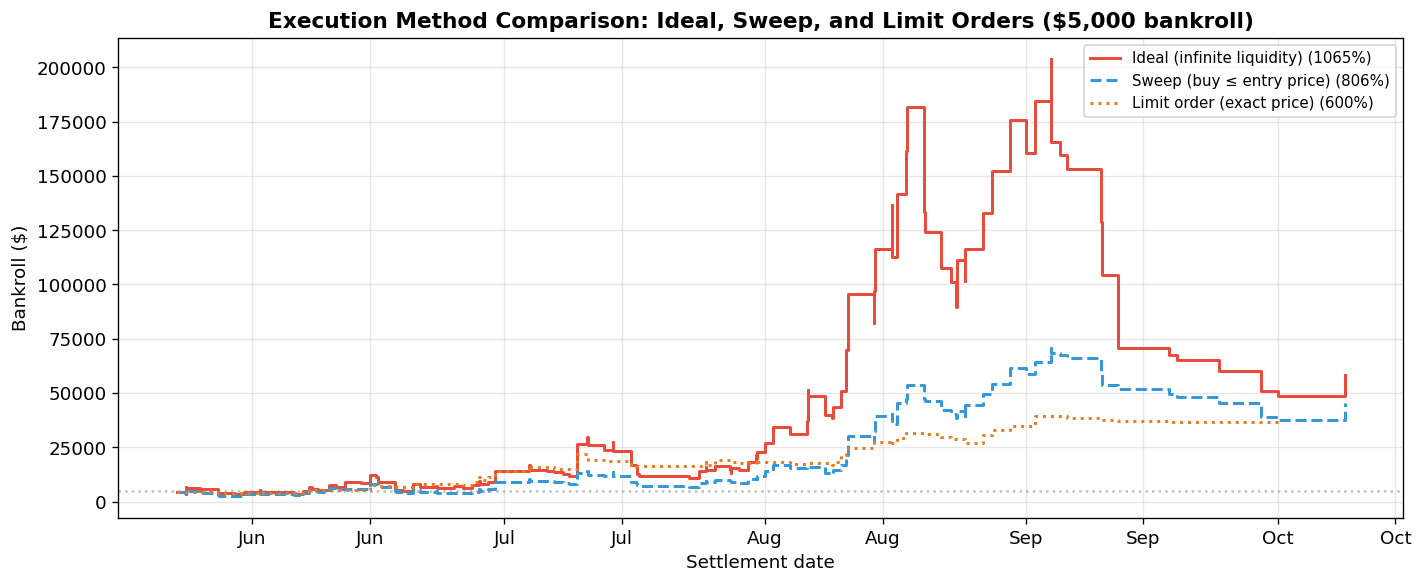

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))
curves = [
    ('Ideal (infinite liquidity)',  eq_ideal_5k, '#e74c3c', '-',  ret_ideal_5k),
    ('Sweep (buy ≤ entry price)',   eq_sweep_5k, '#3498db', '--', ret_sweep_5k),
]
if len(eq_limit_5k) > 0:
    curves.append(('Limit order (exact price)', eq_limit_5k, '#e67e22', ':', ret_limit_5k))
for label, df, color, ls, ret in curves:
    ax.step(df['game_ts'], df['display_bankroll'], where='post',
            color=color, linewidth=1.8, linestyle=ls,
            label=f'{label} ({ret:.0%})')
ax.axhline(BANKROLL_REAL, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Settlement date'); ax.set_ylabel('Bankroll ($)')
ax.set_title('Execution Method Comparison: Ideal, Sweep, and Limit Orders ($5,000 bankroll)',
             fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b'))
plt.tight_layout()
save_fig(fig, 'liq_execution_method_comparison')
plt.show()

### A4. Execution method performance table
**Table:** `liq_execution_method_table` — exact numbers behind the execution-method comparison.

In [15]:
def _row(label, df):
    if df is None or len(df) == 0:
        return {'execution_assumption': label, 'trades': 0, 'mean_fill_rate': np.nan,
                'median_fill_rate': np.nan, 'hit_rate': np.nan,
                'terminal_wealth': BANKROLL_REAL, 'return': 0.0,
                'avg_intended_stake': np.nan, 'avg_realized_stake': np.nan}
    fb = df['bankroll'].iloc[-1]
    return {
        'execution_assumption': label,
        'trades': len(df),
        'mean_fill_rate': df['fill_pct'].mean(),
        'median_fill_rate': df['fill_pct'].median(),
        'hit_rate': df['won'].mean(),
        'terminal_wealth': fb,
        'return': (fb - BANKROLL_REAL) / BANKROLL_REAL,
        'avg_intended_stake': df['wager_ideal'].mean() if 'wager_ideal' in df.columns else df['wager'].mean(),
        'avg_realized_stake': df['wager'].mean(),
    }

method_tbl = pd.DataFrame([
    _row('Ideal (infinite liquidity)', tdf_ideal_5k),
    _row('Sweep (buy ≤ entry price)', tdf_sweep_5k),
    _row('Limit order (exact price)', tdf_limit_5k),
])
save_table(method_tbl, 'liq_execution_method_table')
method_tbl

  saved: outputs\liq_execution_method_table.csv


,execution_assumption,trades,mean_fill_rate,median_fill_rate,hit_rate,terminal_wealth,return,avg_intended_stake,avg_realized_stake
0,Ideal (infinite liquidity),134,1.000000,1.000000,0.402985,58245.690756,10.649138,5492.130237,5492.130237
1,Sweep (buy ≤ entry price),134,0.794425,1.000000,0.402985,45276.149126,8.055230,2272.404426,1434.691129
2,Limit order (exact price),84,0.491899,0.378261,0.440476,35000.699564,6.000140,2184.589149,765.567686


---
## 5. Bootstrap robustness check
**Figure:** `liq_bootstrap_terminal_wealth_distribution`. **Tables:** `liq_bootstrap_terminal_wealth_summary_table`, `liq_bootstrap_terminal_wealth_draws`.

Paired bootstrap (B = 10,000, seed = 42) over the **same intended trade set** at \$5,000 bankroll. Resampling is performed on per-trade gross wealth multipliers `m_i = 1 + pnl_i / W_i` so that compounding is preserved. The same sampled indices are used for both the ideal and the liquidity-constrained execution modes.

This is a *robustness diagnostic*, not a replacement for the realized chronological equity curve.

In [16]:
# --- Build paired trade-level dataframe ---------------------------------
# One row per intended trade in the $5k strategy. Each row carries the
# realized gross wealth multiplier under both execution modes:
#     m_i = 1 + pnl_i / W_i      (W_i = bankroll immediately before trade i)
# under each mode's own bankroll path. Trades with zero fill in the
# constrained engine (no qualifying liquidity) are recorded with
# constrained_gross_multiplier = 1.0 ("no change in bankroll").

# Ideal engine (every entry is taken, by construction)
ideal_paired = tdf_ideal_5k[
    ['game_id','side','entry_px','entry_ts','edge','wager','pnl','bankroll','n_contracts']
].copy()
ideal_paired['bankroll_before_ideal'] = ideal_paired['bankroll'] - ideal_paired['pnl']
ideal_paired['ideal_gross_multiplier'] = (
    1.0 + ideal_paired['pnl'] / ideal_paired['bankroll_before_ideal']
)

# Constrained engine — index by game_id for paired lookup
sweep_idx = tdf_sweep_5k.set_index('game_id') if len(tdf_sweep_5k) else pd.DataFrame()
if len(sweep_idx):
    sweep_lookup = sweep_idx[['pnl','bankroll','n_contracts','fill_pct']].copy()
    sweep_lookup['bankroll_before_constrained'] = sweep_lookup['bankroll'] - sweep_lookup['pnl']
    sweep_lookup['constrained_gross_multiplier'] = (
        1.0 + sweep_lookup['pnl'] / sweep_lookup['bankroll_before_constrained']
    )
else:
    sweep_lookup = pd.DataFrame(columns=[
        'pnl','bankroll','n_contracts','fill_pct',
        'bankroll_before_constrained','constrained_gross_multiplier',
    ])

paired = ideal_paired.copy()
paired = paired.rename(columns={'n_contracts': 'contracts_needed'})
paired['constrained_gross_multiplier'] = (
    paired['game_id'].map(sweep_lookup['constrained_gross_multiplier']).fillna(1.0)
)
paired['fill_rate']        = paired['game_id'].map(sweep_lookup.get('fill_pct', pd.Series(dtype=float))).fillna(0.0)
paired['contracts_filled'] = paired['game_id'].map(sweep_lookup.get('n_contracts', pd.Series(dtype=float))).fillna(0.0)
paired['date']             = pd.to_datetime(paired['game_id'].map(game_dt_map))
paired['market_ticker']    = paired['game_id'].map(home_tickers_k.set_index('game_id')['market_ticker'])
paired['trade_id'] = (
    paired['date'].dt.strftime('%Y-%m-%d') + '_'
    + paired['market_ticker'].astype(str) + '_'
    + paired['side'] + '_'
    + paired['entry_ts'].dt.strftime('%H%M')
)

# Sanity: gross multipliers must be strictly positive.
assert (paired['ideal_gross_multiplier'] > 0).all(),       'nonpositive ideal multiplier'
assert (paired['constrained_gross_multiplier'] > 0).all(), 'nonpositive constrained multiplier'

zero_fill = (paired['constrained_gross_multiplier'] == 1.0).sum()
print(f'Paired intended trades: {len(paired)}')
print(f'Trades with zero fill under sweep (multiplier = 1.0): {zero_fill}')
print(f'Median ideal multiplier:       {paired["ideal_gross_multiplier"].median():.4f}')
print(f'Median constrained multiplier: {paired["constrained_gross_multiplier"].median():.4f}')

Paired intended trades: 134
Trades with zero fill under sweep (multiplier = 1.0): 0
Median ideal multiplier:       0.9565
Median constrained multiplier: 0.9708


In [17]:
# --- Paired bootstrap over per-trade log multipliers --------------------
N_BOOT = 10_000
SEED   = 42
START  = BANKROLL_REAL  # $5,000

g_ideal       = np.log(paired['ideal_gross_multiplier'].values)
g_constrained = np.log(paired['constrained_gross_multiplier'].values)
n_trades      = len(paired)

rng = np.random.default_rng(SEED)
# n_trades-by-N_BOOT index matrix; same indices used for both modes (paired).
idx_matrix = rng.integers(0, n_trades, size=(n_trades, N_BOOT))

logW_ideal       = np.log(START) + g_ideal[idx_matrix].sum(axis=0)
logW_constrained = np.log(START) + g_constrained[idx_matrix].sum(axis=0)
W_ideal          = np.exp(logW_ideal)
W_constrained    = np.exp(logW_constrained)

# Realized chronological terminal wealth (engine output)
realized_ideal       = float(tdf_ideal_5k['bankroll'].iloc[-1])
realized_constrained = float(tdf_sweep_5k['bankroll'].iloc[-1]) if len(tdf_sweep_5k) else float(START)

draws = pd.DataFrame({
    'draw': np.arange(N_BOOT),
    'terminal_wealth_ideal':       W_ideal,
    'terminal_wealth_constrained': W_constrained,
})
save_table(draws, 'liq_bootstrap_terminal_wealth_draws')

def _row(label, W, observed):
    return {
        'execution':       label,
        'observed_terminal_wealth': observed,
        'bootstrap_mean':  float(np.mean(W)),
        'bootstrap_median':float(np.median(W)),
        'p05':             float(np.percentile(W,  5)),
        'p25':             float(np.percentile(W, 25)),
        'p75':             float(np.percentile(W, 75)),
        'p95':             float(np.percentile(W, 95)),
        'pr_above_start':  float((W > START).mean()),
        'pr_above_observed_ideal': float((W > realized_ideal).mean()),
    }

summary_tbl = pd.DataFrame([
    _row('Ideal',                  W_ideal,       realized_ideal),
    _row('Liquidity-constrained',  W_constrained, realized_constrained),
])

# Cross-mode statistics (scalars, attached as a footer row for convenience)
pr_constrained_gt_ideal = float((W_constrained > W_ideal).mean())
median_haircut = 1.0 - float(np.median(W_constrained) / np.median(W_ideal))
print(f'Pr(constrained > ideal) over paired draws: {pr_constrained_gt_ideal:.3f}')
print(f'Median haircut (1 − median_constrained / median_ideal): {median_haircut:.3f}')

summary_tbl.attrs['pr_constrained_gt_ideal'] = pr_constrained_gt_ideal
summary_tbl.attrs['median_haircut']          = median_haircut
save_table(summary_tbl, 'liq_bootstrap_terminal_wealth_summary_table')
summary_tbl

  saved: outputs\liq_bootstrap_terminal_wealth_draws.csv
Pr(constrained > ideal) over paired draws: 0.401
Median haircut (1 − median_constrained / median_ideal): 0.226
  saved: outputs\liq_bootstrap_terminal_wealth_summary_table.csv


,execution,observed_terminal_wealth,bootstrap_mean,bootstrap_median,p05,p25,p75,p95,pr_above_start,pr_above_observed_ideal
0,Ideal,58245.690756,424447.918818,56149.931988,2321.994426,14982.557088,217337.752894,1.580720e+06,0.8926,0.4922
1,Liquidity-constrained,45276.149126,161935.372021,43472.967873,3669.520001,15679.842047,130525.988688,6.188651e+05,0.9215,0.4269


  saved: outputs\liq_bootstrap_terminal_wealth_distribution.png


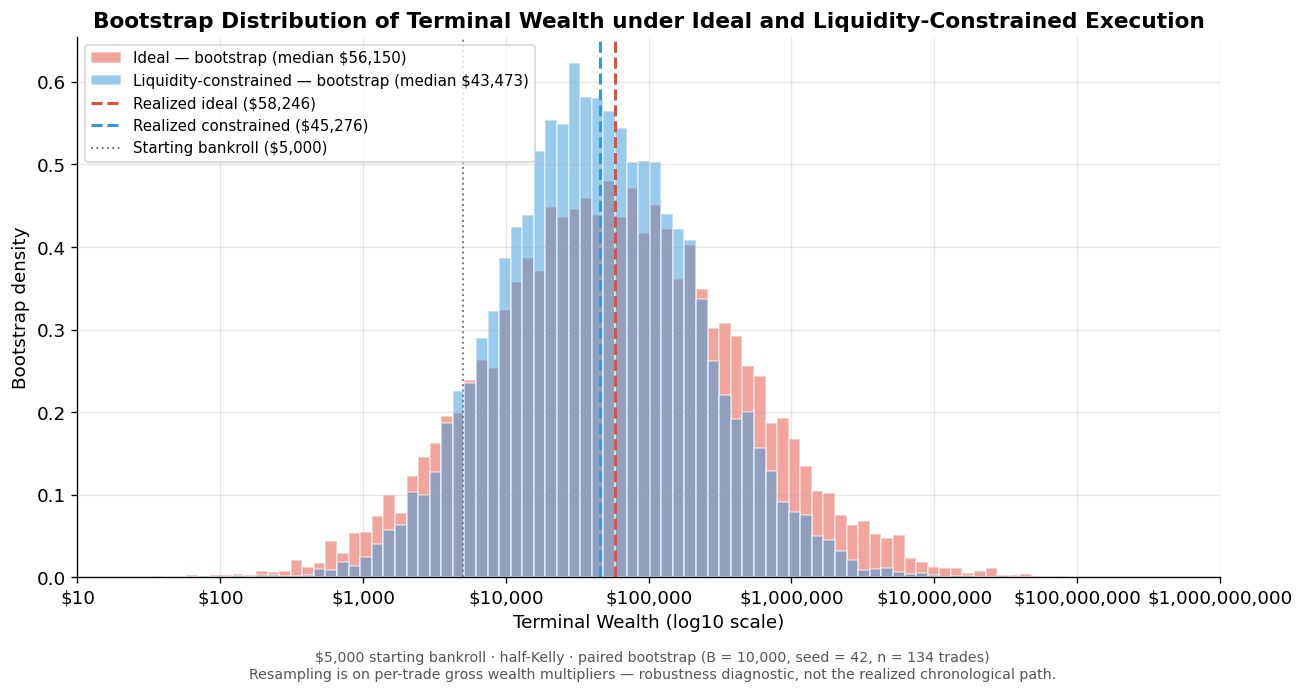

In [18]:
# --- Bootstrap distribution figure --------------------------------------
# Overlaid histograms of log10 terminal wealth (terminal wealth is heavy-
# right-tailed so a log axis keeps both tails visible). Vertical lines mark
# the realized chronological terminal wealth from the engine.

log10_ideal       = np.log10(W_ideal)
log10_constrained = np.log10(W_constrained)
log10_real_ideal       = np.log10(realized_ideal)
log10_real_constrained = np.log10(realized_constrained)

med_ideal       = np.median(W_ideal)
med_constrained = np.median(W_constrained)

fig, ax = plt.subplots(figsize=(11, 5.5))

bins = np.linspace(
    min(log10_ideal.min(), log10_constrained.min()),
    max(log10_ideal.max(), log10_constrained.max()),
    80,
)
ax.hist(log10_ideal, bins=bins, alpha=0.5, color='#e74c3c',
        edgecolor='white', density=True,
        label=f'Ideal — bootstrap (median ${med_ideal:,.0f})')
ax.hist(log10_constrained, bins=bins, alpha=0.5, color='#3498db',
        edgecolor='white', density=True,
        label=f'Liquidity-constrained — bootstrap (median ${med_constrained:,.0f})')

ax.axvline(log10_real_ideal, color='#e74c3c', linestyle='--', linewidth=1.8,
           label=f'Realized ideal (${realized_ideal:,.0f})')
ax.axvline(log10_real_constrained, color='#3498db', linestyle='--', linewidth=1.8,
           label=f'Realized constrained (${realized_constrained:,.0f})')
ax.axvline(np.log10(START), color='gray', linestyle=':', linewidth=1.2,
           label=f'Starting bankroll (${START:,.0f})')

# Tick labels in dollars on a log10 scale for legibility
xmin, xmax = ax.get_xlim()
tick_decades = np.arange(int(np.floor(xmin)), int(np.ceil(xmax)) + 1)
ax.set_xticks(tick_decades)
ax.set_xticklabels([f'${10**t:,.0f}' for t in tick_decades])

ax.set_xlabel('Terminal Wealth (log10 scale)')
ax.set_ylabel('Bootstrap density')
ax.set_title('Bootstrap Distribution of Terminal Wealth under Ideal and Liquidity-Constrained Execution',
             fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Caption-style annotation
caption = (
    f'$5,000 starting bankroll · half-Kelly · paired bootstrap '
    f'(B = {N_BOOT:,}, seed = {SEED}, n = {n_trades} trades)\n'
    'Resampling is on per-trade gross wealth multipliers — robustness '
    'diagnostic, not the realized chronological path.'
)
fig.text(0.5, -0.04, caption, ha='center', fontsize=8.5, color='#555555')

plt.tight_layout()
save_fig(fig, 'liq_bootstrap_terminal_wealth_distribution')
plt.show()

In [19]:
print('All liquidity outputs written to:', OUTPUTS_DIR)
for p in sorted(OUTPUTS_DIR.glob('liq_*')):
    print(' ', p.name)

All liquidity outputs written to: C:\Users\arius\Desktop\kalshi_wnba_bot\organized\outputs
  liq_bootstrap_terminal_wealth_distribution.png
  liq_bootstrap_terminal_wealth_draws.csv
  liq_bootstrap_terminal_wealth_summary_table.csv
  liq_capacity_by_starting_bankroll.png
  liq_equity_ideal_vs_constrained.png
  liq_execution_method_comparison.png
  liq_execution_method_table.csv
  liq_execution_summary_table.csv
  liq_fill_rate_vs_wager_size.png
  liq_fillability_counts_table.csv
  liq_fillability_diagnostics_grid.png
